## importing librarys and load data

In [ ]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_excel(r"C:\Users\VIP\Downloads\online+retail\Online Retail.xlsx")

## Data Preprocessing & Feature engineering


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df = df[~df['InvoiceNo'].astype('str').str.startswith('C')]

In [7]:
print(df.duplicated().sum() , "duplicated value")
df = df.drop_duplicates()

5231 duplicated value


## handiling missing values

In [8]:
max_id = df.CustomerID.max()
null_ids = df.CustomerID.isna()
null_ids = null_ids[null_ids == True]
df.loc[null_ids.index,'CustomerID'] = np.arange(max_id + 1,max_id + null_ids.sum() + 1)

In [9]:
df.CustomerID.isna().sum()

np.int64(0)

In [10]:
print(df.isna().sum().sum())
df.dropna(inplace=True)

1454


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525936 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525936 non-null  object        
 1   StockCode    525936 non-null  object        
 2   Description  525936 non-null  object        
 3   Quantity     525936 non-null  int64         
 4   InvoiceDate  525936 non-null  datetime64[ns]
 5   UnitPrice    525936 non-null  float64       
 6   CustomerID   525936 non-null  float64       
 7   Country      525936 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.1+ MB


In [12]:
df=df[df['Quantity']>0]
df = df[df['UnitPrice'] > 0]

In [13]:
df['total_price']=df['Quantity']*df['UnitPrice']

In [14]:
df['total_price'] = df['total_price'].clip(lower=0)

### Create RFM features: 

In [15]:
# create RFM Recency Frequency Monetary features
snapshot_date=df['InvoiceDate'].max()+ pd.Timedelta(days=1)
df['Recency']=df.groupby('CustomerID')['InvoiceDate'].transform(lambda x:(snapshot_date-x.max()).days)

df['Frequency']=df.groupby('CustomerID')['InvoiceNo'].transform('nunique')

df['Monetary']=df.groupby('CustomerID')['total_price'].transform('sum')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  float64       
 7   Country      524878 non-null  object        
 8   total_price  524878 non-null  float64       
 9   Recency      524878 non-null  int64         
 10  Frequency    524878 non-null  int64         
 11  Monetary     524878 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 52.1+ MB


In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Recency,Frequency,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,372,34,5391.21
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,372,34,5391.21
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21


## Create CLV

#### before CLV

In [18]:
df['AverageOrderValue'] = df['Monetary'] / df['Frequency']  

In [19]:
df['FirstPurchase'] = df.groupby('CustomerID')['InvoiceDate'].transform('min')
df['LastPurchase'] = df.groupby('CustomerID')['InvoiceDate'].transform('max')

df['CustomerAgeDays'] = (df['LastPurchase'] - df['FirstPurchase']).dt.days + 1 
df['CustomerAgeMonth'] = df['CustomerAgeDays'] / 30

In [20]:
df['FrequencyPerMonth'] = df['Frequency'] / df['CustomerAgeMonth']

In [21]:
df['RecencyMonth'] = df['Recency']/30

In [22]:
df['CLV'] = df['FrequencyPerMonth'] * df['AverageOrderValue'] * 3 # 3 is customer lifespan
df['CLV'] = df['CLV'] * (1/( df['RecencyMonth']+1)) # make the CLV related to new customers

### add important features for model to predict CLV 

In [23]:
#n.of differnt product that the customer buy
df['ProductDiversity'] = df.groupby('CustomerID')['StockCode'].transform('nunique') 

In [24]:
# dictionary for each category
category_keywords = {
    "Fashion": ["bag", "dress", "shirt","shoes", "jacket", "coat"],
    "Home": [ "bunting", "holder","candle", "lamp", "light"],
    "Kitchen": ["cakestand", "cup", "mug", "plate", "knife", "fork", "spoon", "kettle", "bottle", "glass"],
    "Stationery": ["card", "craft", "letter","notebook", "pen", "pencil"],
    "Accessories": ["key ring", "bling","jewelry","ring"]
}
# function
def extract_category(text):
    text = str(text).lower()
    for category, keywords in category_keywords.items():
        if any(word in text for word in keywords):
            return category
    return "Other"

#identify product category 
df['ProductCategory'] = df['Description'].apply(extract_category)

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Recency,...,AverageOrderValue,FirstPurchase,LastPurchase,CustomerAgeDays,CustomerAgeMonth,FrequencyPerMonth,RecencyMonth,CLV,ProductDiversity,ProductCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Home
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Fashion
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Kitchen
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Other


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   InvoiceNo          524878 non-null  object        
 1   StockCode          524878 non-null  object        
 2   Description        524878 non-null  object        
 3   Quantity           524878 non-null  int64         
 4   InvoiceDate        524878 non-null  datetime64[ns]
 5   UnitPrice          524878 non-null  float64       
 6   CustomerID         524878 non-null  float64       
 7   Country            524878 non-null  object        
 8   total_price        524878 non-null  float64       
 9   Recency            524878 non-null  int64         
 10  Frequency          524878 non-null  int64         
 11  Monetary           524878 non-null  float64       
 12  AverageOrderValue  524878 non-null  float64       
 13  FirstPurchase      524878 non-null  datetime64[ns

In [27]:
df['CLV'].value_counts()

CLV
9190.487903     7676
33557.049122    5670
52804.601741    5111
7718.032777     4412
2819.822278     2677
                ... 
20503.451613       1
6578.419355        1
1375.258065        1
3759.096774        1
3248.709677        1
Name: count, Length: 31324, dtype: int64

In [28]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'total_price', 'Recency',
       'Frequency', 'Monetary', 'AverageOrderValue', 'FirstPurchase',
       'LastPurchase', 'CustomerAgeDays', 'CustomerAgeMonth',
       'FrequencyPerMonth', 'RecencyMonth', 'CLV', 'ProductDiversity',
       'ProductCategory'],
      dtype='object')

In [29]:
df2 = df[['Quantity','UnitPrice','total_price','Frequency', 'Monetary', 'Recency','Country','ProductCategory','ProductDiversity','CLV']]

In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Quantity          524878 non-null  int64  
 1   UnitPrice         524878 non-null  float64
 2   total_price       524878 non-null  float64
 3   Frequency         524878 non-null  int64  
 4   Monetary          524878 non-null  float64
 5   Recency           524878 non-null  int64  
 6   Country           524878 non-null  object 
 7   ProductCategory   524878 non-null  object 
 8   ProductDiversity  524878 non-null  int64  
 9   CLV               524878 non-null  float64
dtypes: float64(4), int64(4), object(2)
memory usage: 44.0+ MB


In [31]:
df2['Country'].unique()       

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Bahrain', 'Israel', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

## Encoding catrgorical features

In [32]:
##encoding
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df2['ProductCategory'] = encoder.fit_transform(df2[['ProductCategory']])
df2['Country'] = encoder.fit_transform(df2[['Country']])



In [33]:
df2.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity,CLV
0,6,2.55,15.30,34,5391.21,372,36.0,2.0,21,18104.809701
1,6,3.39,20.34,34,5391.21,372,36.0,4.0,21,18104.809701
2,8,2.75,22.00,34,5391.21,372,36.0,1.0,21,18104.809701
3,6,3.39,20.34,34,5391.21,372,36.0,3.0,21,18104.809701
4,6,3.39,20.34,34,5391.21,372,36.0,4.0,21,18104.809701


In [34]:
df2['ProductCategory'].value_counts()

ProductCategory
4.0    330162
1.0     54933
2.0     47537
3.0     44648
5.0     41284
0.0      6314
Name: count, dtype: int64

In [35]:
df2['Country'].unique()

array([36., 13.,  0., 24., 14., 25., 10., 33., 31., 26., 27., 19.,  3.,
       22., 20., 17.,  6.,  9.,  7., 32., 12.,  1.,  2., 18., 15., 16.,
       30., 21., 35., 29.,  8.,  5., 37.,  4., 34., 11., 23., 28.])

## split data into x,y fratures and target

In [36]:
# target
y = df2['CLV']
# features
x = df2.drop(columns=['CLV'])

## split data into train and test 

In [37]:
##split data 
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (419902, 9)
x_test shape: (104976, 9)
y_train shape: (419902,)
y_test shape: (104976,)


In [38]:
x_train.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity
291727,4,0.42,1.68,13,5030.07,33,36.0,5.0,299
365923,1,1.25,1.25,1,1.25,72,36.0,4.0,1
70577,12,1.25,15.00,18,4397.30,3,36.0,3.0,331
539925,2,1.45,2.90,10,1196.50,1,36.0,4.0,142
401623,1,4.13,4.13,17,65164.79,4,36.0,4.0,1119


## scaling after split to prevent data leakage

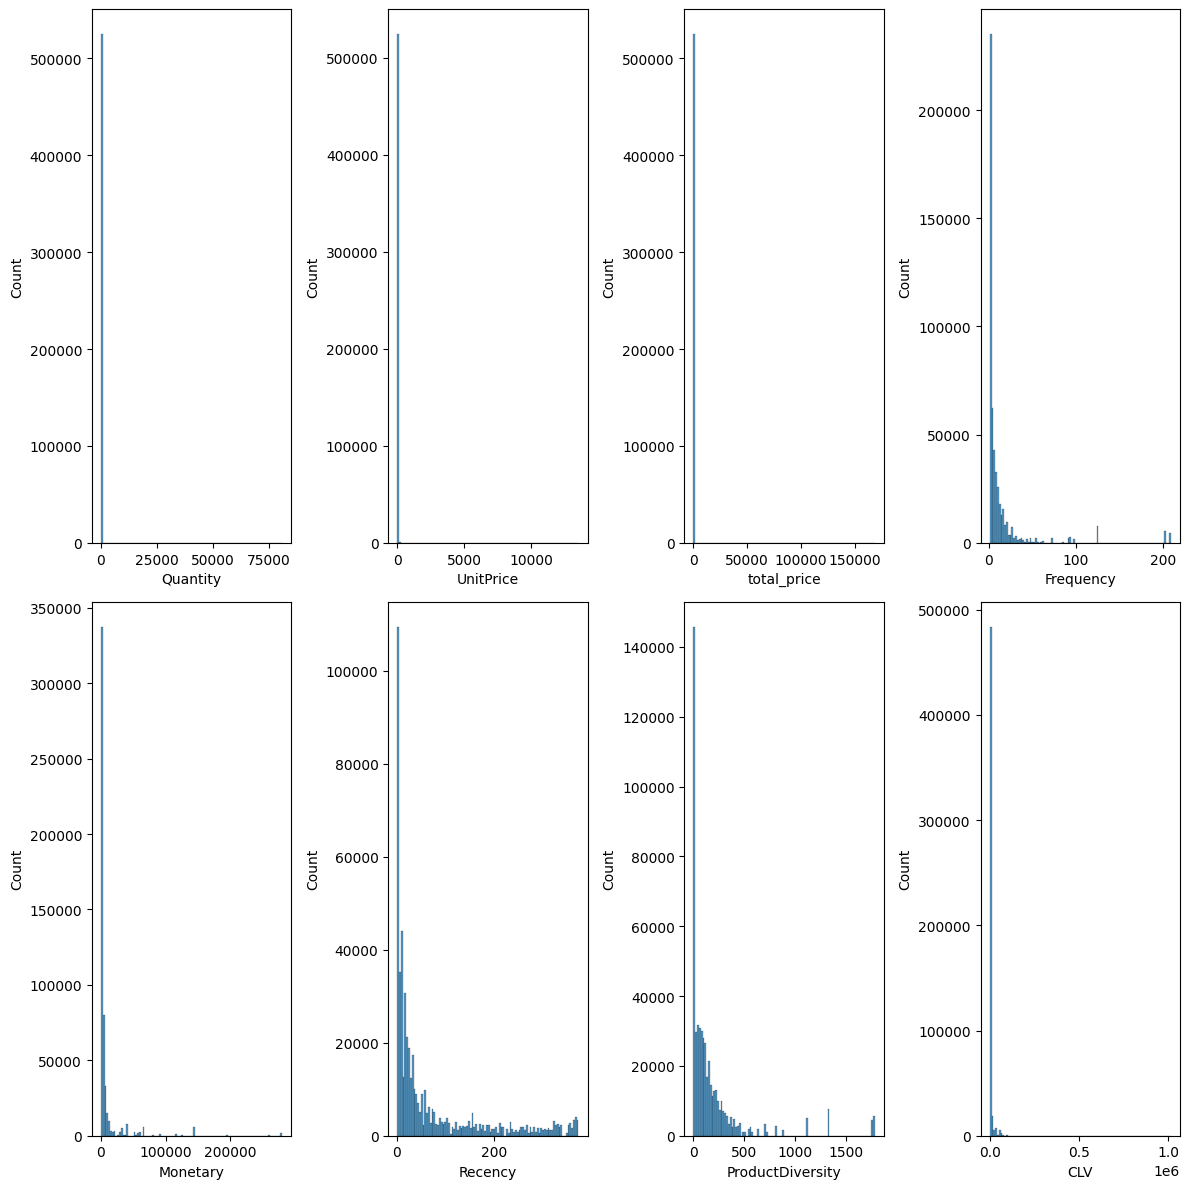

In [39]:
num_cols = ['Quantity', 'UnitPrice', 'total_price', 'Frequency', 'Monetary',
       'Recency','ProductDiversity', 'CLV']
plt.figure(figsize=(12,12))
for i in range(8):
    plt.subplot(2,4,i+1)
    sns.histplot(data=df2,x=num_cols[i],bins=100)
plt.tight_layout()

In [40]:
# all data are skewed

# Apply log1p on train
x_train = np.log1p(x_train)

# Apply log1p on test (using same formula, no fit needed)
x_test = np.log1p(x_test)


y_train= np.log1p(y_train)
y_test= np.log1p(y_test)

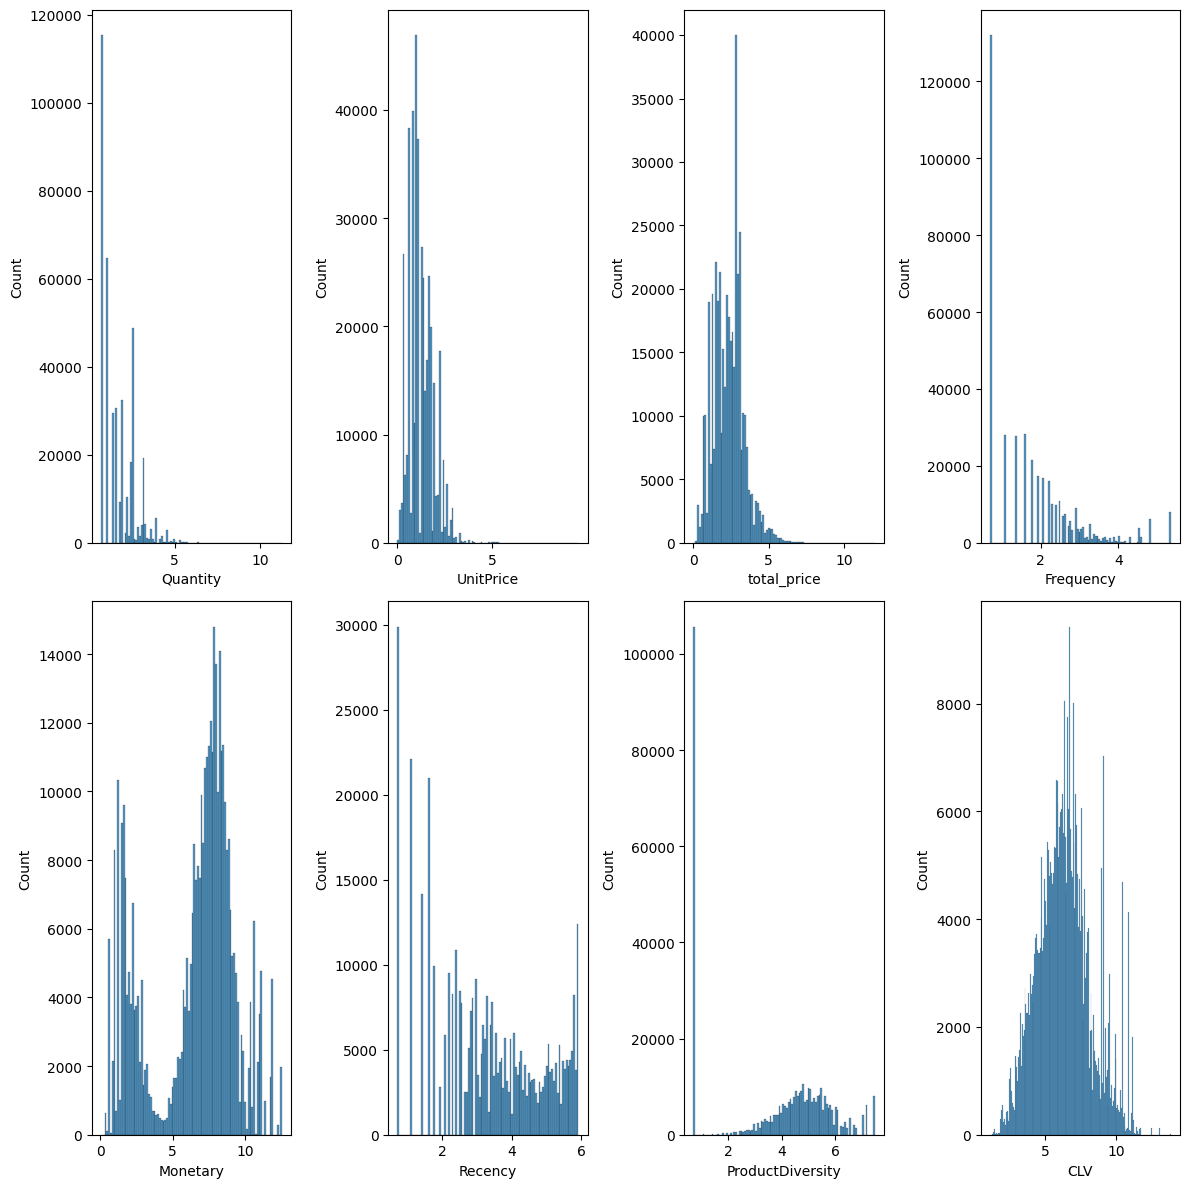

In [41]:
# now data are more normal distributed
num_cols = ['Quantity', 'UnitPrice', 'total_price', 'Frequency', 'Monetary',
       'Recency','ProductDiversity', 'CLV']
plt.figure(figsize=(12,12))
for i in range(7):
    plt.subplot(2,4,i+1)
    sns.histplot(data=x_train,x=num_cols[i],bins=100)
plt.subplot(2,4,8)
sns.histplot(y_train)
plt.tight_layout()
    

In [42]:
x_train.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity
291727,1.609438,0.350657,0.985817,2.639057,8.523388,3.526361,3.610918,1.791759,5.703782
365923,0.693147,0.810930,0.810930,0.693147,0.810930,4.290459,3.610918,1.609438,0.693147
70577,2.564949,0.810930,2.772589,2.944439,8.388973,1.386294,3.610918,1.386294,5.805135
539925,1.098612,0.896088,1.360977,2.397895,7.087991,0.693147,3.610918,1.609438,4.962845
401623,0.693147,1.635106,1.635106,2.890372,11.084690,1.609438,3.610918,1.609438,7.021084


# ML Model

## Supervised Learning

### Linear Regression

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
rfm = ['Recency','Frequency','Monetary']
X_train_rfm = x_train[rfm].copy()
X_test_rfm  = x_test[rfm].copy()
# call
lin_rfm = LinearRegression()

# Fit
lin_rfm.fit(X_train_rfm, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred_lr = lin_rfm.predict(X_test_rfm)

In [45]:
print("Linear Regression:")
print("RMSE:", np.sqrt(mse(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression:
RMSE: 1.2381110407753488
MAE: 0.9560873597459588
R2: 0.5627004904283339


### Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor
# call
rf = RandomForestRegressor(n_estimators=200, random_state=42)
# fit
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred_rf = rf.predict(x_test)

In [48]:
print("Random Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest:
RMSE: 0.013350330109195365
MAE: 0.0008264103844805612
R2: 0.9999491555204212


### XGBoost

In [49]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Baseline XGBoost

In [50]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    random_state=42
)

xgb_base.fit(x_train, y_train)

y_pred_xgb = xgb_base.predict(x_test)

print("XGBoost Baseline:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))


XGBoost Baseline:
RMSE: 0.14256290075758704
MAE: 0.06283102442314384
R2: 0.9942020716459851


### XGBoost with Hypertuning

In [51]:
param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}
# call xgregressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)



In [52]:
# call cv
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    random_state=42
)
# fit
xgb_search.fit(x_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
print("Best Params:", xgb_search.best_params_)

Best Params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [54]:
best_xgb = xgb_search.best_estimator_
# predict
y_pred_best = best_xgb.predict(x_test)



In [55]:
print("Tuned XGBoost:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("R2:", r2_score(y_test, y_pred_best))

Tuned XGBoost:
RMSE: 0.10686985274722541
MAE: 0.04488267727622301
R2: 0.9967418564158699


In [56]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_best)

print("RMSE (Real CLV):", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))
print("MAE (Real CLV):", mean_absolute_error(y_test_real, y_pred_real))
print("R2 (Real CLV):", r2_score(y_test_real, y_pred_real))


RMSE (Real CLV): 1124.5069637827323
MAE (Real CLV): 117.06058498051654
R2 (Real CLV): 0.9933543674804957


### Feature Importance

In [57]:
importances = best_xgb.feature_importances_
fi = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


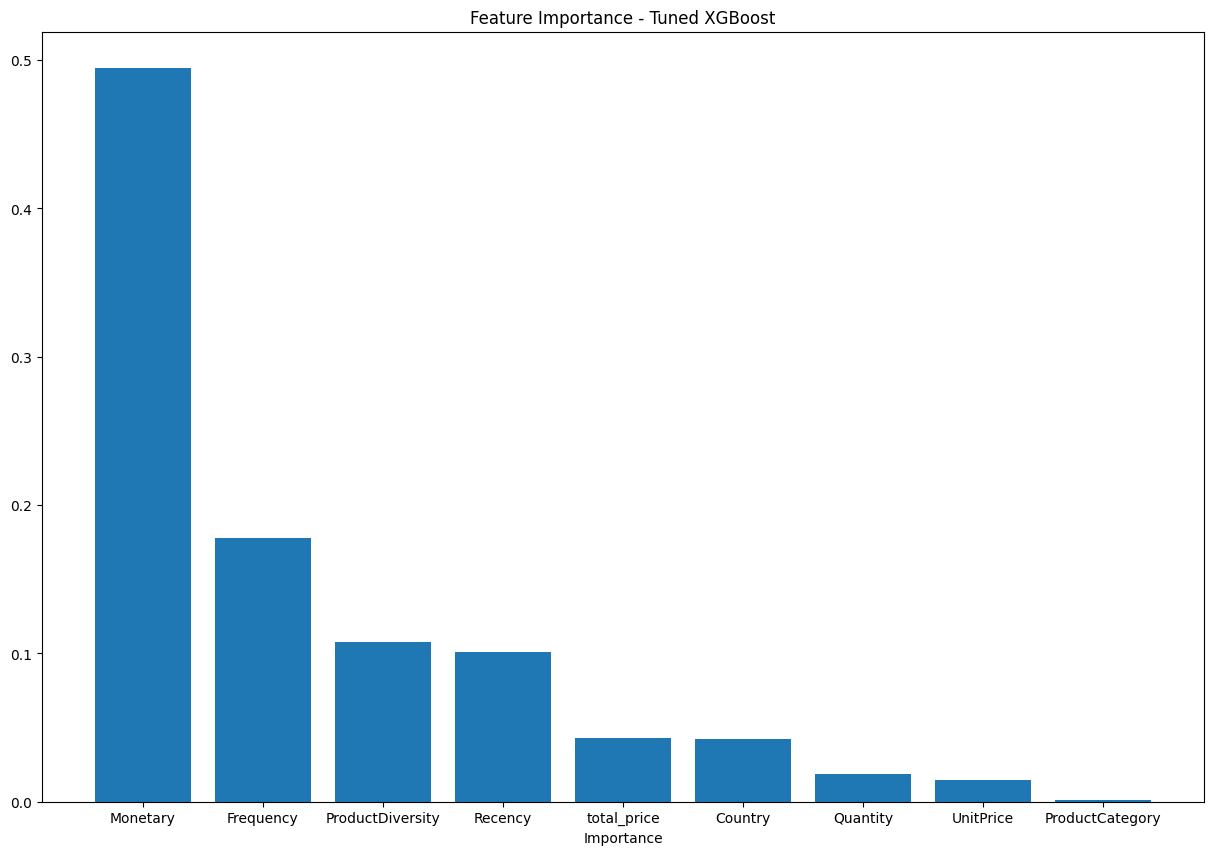

In [58]:
plt.figure(figsize=(15,10))
plt.bar(fi['Feature'], fi['Importance'])
plt.title('Feature Importance - Tuned XGBoost')
plt.xlabel('Importance')
plt.show()

### expm1 for models

In [59]:
# True Real CLV
y_test_real = np.expm1(y_test)

# Linear Regression
y_pred_lr_real = np.expm1(y_pred_lr)

# Random Forest
y_pred_rf_real = np.expm1(y_pred_rf)

# XGBoost Tuned
y_pred_xgb_real = np.expm1(y_pred_best)


### LR vs RF vs XGBoost

In [60]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_real, y_pred_lr_real)),
        np.sqrt(mean_squared_error(y_test_real, y_pred_rf_real)),
        np.sqrt(mean_squared_error(y_test_real, y_pred_xgb_real))
    ],
    'MAE': [
        mean_absolute_error(y_test_real, y_pred_lr_real),
        mean_absolute_error(y_test_real, y_pred_rf_real),
        mean_absolute_error(y_test_real, y_pred_xgb_real)
    ],
    'R2': [
        r2_score(y_test_real, y_pred_lr_real),
        r2_score(y_test_real, y_pred_rf_real),
        r2_score(y_test_real, y_pred_xgb_real)
    ]
})

comparison


,Model,RMSE,MAE,R2
0,Linear Regression,13530.218805,3047.980523,0.037897
1,Random Forest,352.904170,4.445962,0.999345
2,Tuned XGBoost,1124.506964,117.060585,0.993354
